# 📊 Análisis de Calidad del Aire en Beijing (2013–2017)
### Trabajo Universitario · Parte B: Python EDA

*Dataset: Beijing Multi-Site Air-Quality*

---

## Índice
1. [Carga del dataset y variables](#carga)
2. [Distribución de contaminantes por estación](#estaciones)
3. [Estacionalidad mensual del PM2.5](#estacionalidad)
4. [Ciclo diario: PM2.5 vs NO2](#horario)
5. [Suavizado temporal: Rolling vs EWMA](#suavizado)
6. [Heatmap: hora del día × día de la semana](#heatmap)
7. [Clasificación AQI de episodios](#aqi)
8. [Matriz de correlación](#correlacion)
9. [🏛 Decálogo de recomendaciones al Ayuntamiento](#decalogo)

---
> **Umbrales de referencia usados en este análisis**
> - OMS 2021: PM2.5 ≤ 15 µg/m³ (media 24h) · NO2 ≤ 25 µg/m³ (media 24h)
> - China GB 3095-2012: PM2.5 ≤ 35 µg/m³ (media anual) · NO2 ≤ 40 µg/m³ (media anual)

---
<a id='carga'></a>
## 1. Carga del dataset y variables

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import numpy as np

# Estilo global: sobrio y limpio
sns.set_style("whitegrid")
sns.set_palette("muted")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

ruta_reports = '../reports/'
os.makedirs(ruta_reports, exist_ok=True)

# Carga del dataset ya limpio
df = pd.read_csv('../data/processed/beijing_unified_cleaned.csv',
                 index_col='date', parse_dates=True)

# Columnas de tiempo que reutilizaremos
df['hour']     = df.index.hour
df['month']    = df.index.month
df['day_name'] = df.index.day_name()

print(f"Registros: {len(df):,}  |  Columnas: {df.shape[1]}")
print(f"Periodo  : {df.index.min().date()} → {df.index.max().date()}")
print(f"Estaciones ({df['station'].nunique()}): {sorted(df['station'].unique())}")
df.head()

Registros: 420,768  |  Columnas: 16
Periodo  : 2013-03-01 → 2017-02-28
Estaciones (12): ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,hour,month,day_name
date,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,0,3,Friday
2013-03-01 01:00:00,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,1,3,Friday
2013-03-01 02:00:00,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2,3,Friday
2013-03-01 03:00:00,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,3,3,Friday
2013-03-01 04:00:00,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,4,3,Friday


### Diccionario de variables

| Columna | Nombre completo | Categoría | Descripción | Relevancia |
|:---|:---|:---|:---|:---|
| **PM2.5** | Partículas Finas (<2.5 µm) | Contaminante | Penetran en el torrente sanguíneo | ⭐ Indicador principal de riesgo |
| **PM10** | Partículas Gruesas (<10 µm) | Contaminante | Polvo, polen, moho | Sube junto a PM2.5 en combustión |
| **SO2** | Dióxido de Azufre | Contaminante | Gas de quema de carbón | Indicador de industria y calefacción |
| **NO2** | Dióxido de Nitrógeno | Contaminante | Motores de combustión | Indicador directo de tráfico rodado |
| **CO** | Monóxido de Carbono | Contaminante | Combustión incompleta | Fuertemente ligado al PM2.5 |
| **O3** | Ozono Troposférico | Contaminante | Reacción fotoquímica solar | Sube en verano; baja donde hay NO2 |
| **TEMP** | Temperatura | Meteorología | Grados Celsius | Clave: la inversión térmica nocturna atrapa contaminantes |
| **PRES** | Presión atmosférica | Meteorología | hPa | Alta presión = aire estancado |
| **DEWP** | Punto de Rocío | Meteorología | Humedad del aire | Favorece la niebla tóxica |
| **RAIN** | Lluvia | Meteorología | mm | "Efecto lavado": limpia el aire |
| **wd** | Dirección del viento | Meteorología | N/S/E/W | Sur = industrial (Hebei) |
| **WSPM** | Velocidad del viento | Meteorología | m/s | Más viento → más dispersión |
| **station** | Estación | Metadatos | Nombre del sensor | Para análisis espacial |

---
<a id='estaciones'></a>
## 2. Distribución de contaminantes por estación

Comparamos la **mediana** de PM2.5, NO2 y O3 en cada una de las 12 estaciones.
Usamos la mediana en lugar de la media para evitar que los episodios extremos distorsionen la comparativa.
Las barras se colorean en rojo si la estación supera el límite OMS y en verde si lo cumple.

✅ Guardado: 01_comparativa_estaciones.png


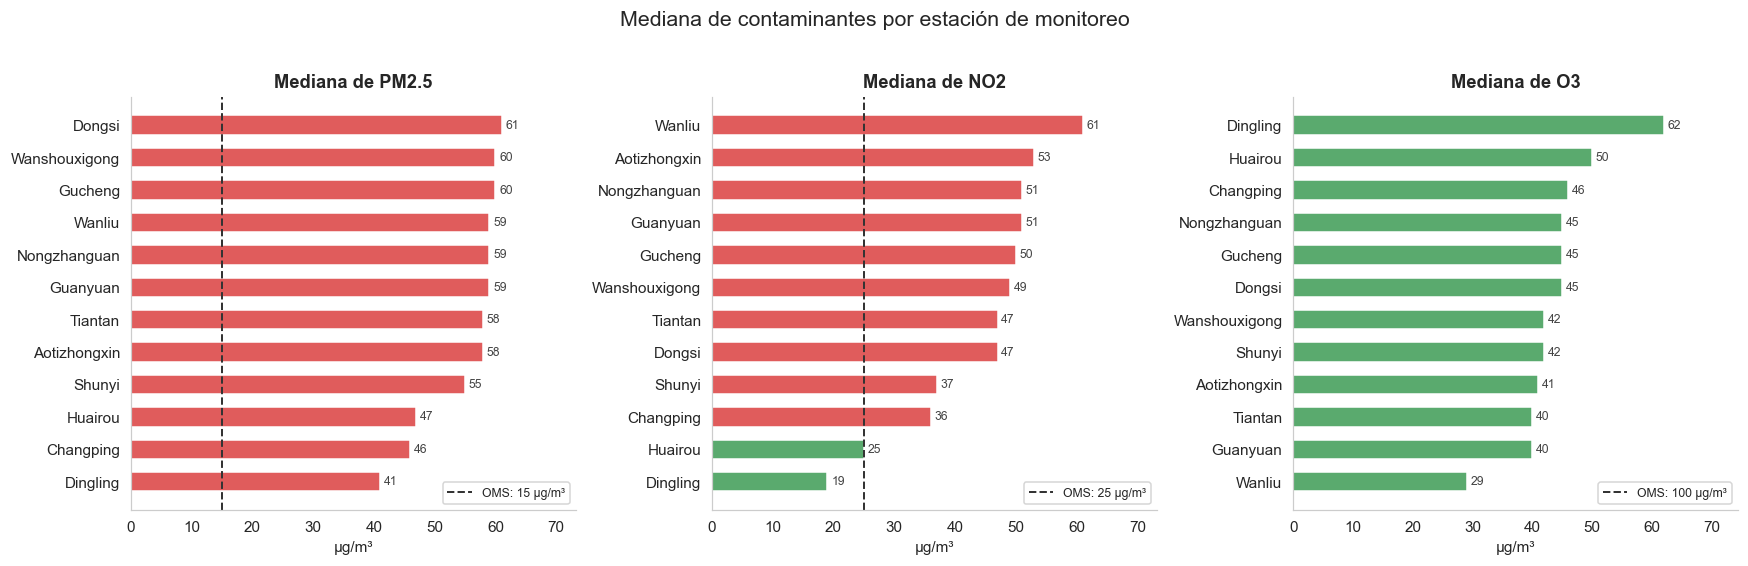

In [67]:
# Límites OMS 2021 para cada contaminante (µg/m³)
limites_oms = {'PM2.5': 15, 'NO2': 25, 'O3': 100}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, poll in zip(axes, ['PM2.5', 'NO2', 'O3']):
    medianas = df.groupby('station')[poll].median().sort_values()
    limite   = limites_oms[poll]
    colores  = ['#e05c5c' if v > limite else '#5aaa6e' for v in medianas.values]

    ax.barh(medianas.index, medianas.values, color=colores, height=0.6, edgecolor='white')

    # Valor numérico al final de cada barra
    for i, v in enumerate(medianas.values):
        ax.text(v + medianas.max() * 0.01, i, f'{v:.0f}',
                va='center', fontsize=8, color='#444')

    # Línea del límite OMS
    ax.axvline(limite, color='#333', linestyle='--', linewidth=1.3,
               label=f'OMS: {limite} µg/m³')

    ax.set_title(f'Mediana de {poll}', fontsize=12, fontweight='bold')
    ax.set_xlabel('µg/m³')
    ax.set_xlim(0, medianas.max() * 1.2)
    ax.legend(fontsize=8)
    ax.grid(False)

fig.suptitle('Mediana de contaminantes por estación de monitoreo', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '01_comparativa_estaciones.png'), bbox_inches='tight')
print("✅ Guardado: 01_comparativa_estaciones.png")
plt.show()

### 🔍 Conclusión

**PM2.5 — todas las barras en rojo.** Ninguna de las 12 estaciones cumple el límite OMS de 15 µg/m³.
Las medianas oscilan entre ~40 y ~60 µg/m³, entre **2,5 y 4 veces el límite permitido**.
Esto confirma que la contaminación por partículas finas en Beijing no es un problema puntual de una zona, sino **un fallo sistémico de toda la ciudad**.

Las estaciones más contaminadas (Dongsi, Gucheng, Wanshouxigong) coinciden con el centro urbano de alta densidad de tráfico y calefacción doméstica.
Las menos contaminadas (Dingling, Huairou, Changping) son zonas periurbanas, aunque igualmente superan el límite.

**NO2** refleja la huella del tráfico: las estaciones del centro registran valores más altos, con varias rozando el límite OMS de 25 µg/m³.

**O3** muestra el patrón inverso al NO2 (el NO2 del tráfico destruye el ozono a nivel de calle, fenómeno conocido como *titulación química*).

> *Referencia: OMS Air Quality Guidelines 2021 — WHO/HEP/ECH/AQH/2021.1*

---
<a id='estacionalidad'></a>
## 3. Estacionalidad mensual del PM2.5

Agrupamos los registros horarios por mes para observar el **patrón estacional anual**.
Añadimos las líneas de referencia legal: límite chino (35 µg/m³) y límite OMS (15 µg/m³).
La distancia entre los valores reales y estas líneas muestra el nivel de incumplimiento normativo.

✅ Guardado: 02_estacionalidad_mensual.png


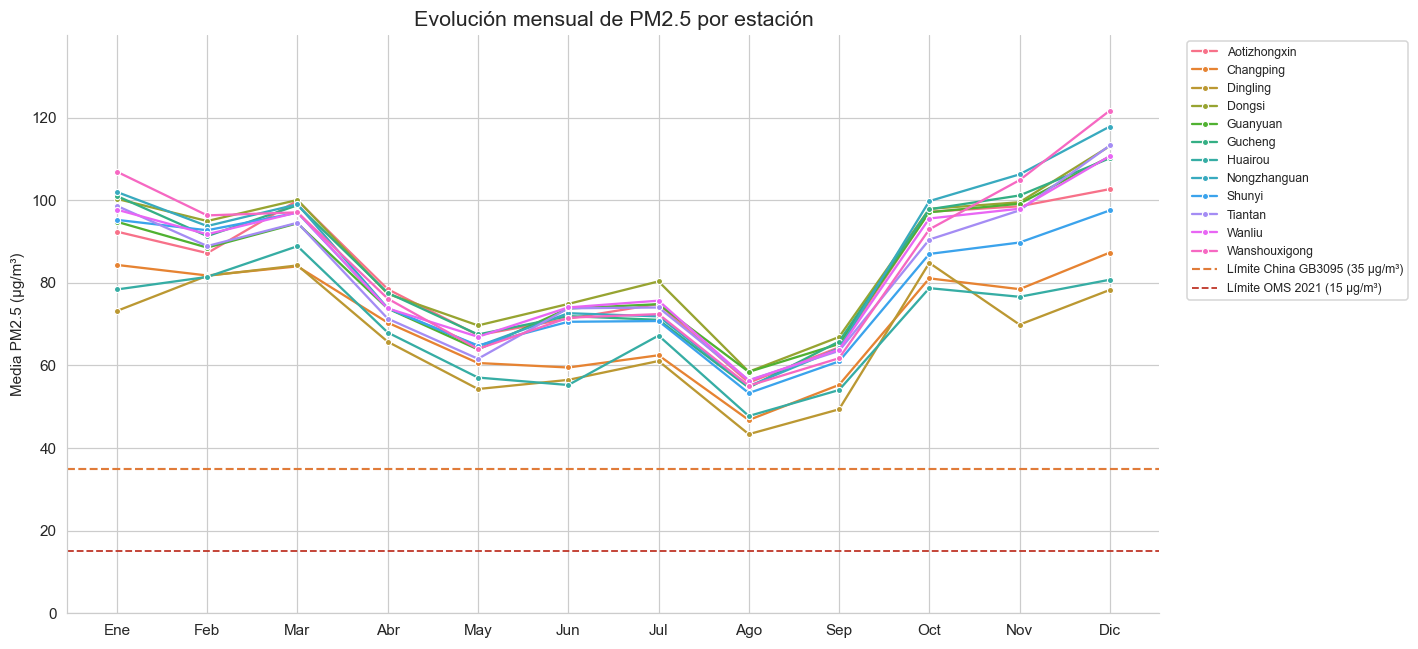

Media global de PM2.5 por mes:
  Ene:  93.8 µg/m³  ❌ supera límite China
  Feb:  89.2 µg/m³  ❌ supera límite China
  Mar:  94.6 µg/m³  ❌ supera límite China
  Abr:  73.4 µg/m³  ❌ supera límite China
  May:  63.5 µg/m³  ❌ supera límite China
  Jun:  68.8 µg/m³  ❌ supera límite China
  Jul:  71.4 µg/m³  ❌ supera límite China
  Ago:  53.5 µg/m³  ❌ supera límite China
  Sep:  61.3 µg/m³  ❌ supera límite China
  Oct:  91.7 µg/m³  ❌ supera límite China
  Nov:  93.3 µg/m³  ❌ supera límite China
  Dic: 103.7 µg/m³  ❌ supera límite China


In [70]:
# Media de PM2.5 por mes y estación
estacionalidad = df.groupby(['month', 'station'])['PM2.5'].mean().reset_index()
estacionalidad.columns = ['month', 'station', 'avg_pm25']

# Etiquetas de meses en español
meses = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
         7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

plt.figure(figsize=(13, 6))
sns.lineplot(data=estacionalidad, x='month', y='avg_pm25',
             hue='station', marker='o', linewidth=1.5, markersize=4)

# Límites normativos
plt.axhline(35, color='#e07b39', linestyle='--', linewidth=1.4,
            label='Límite China GB3095 (35 µg/m³)')
plt.axhline(15, color='#c0392b', linestyle='--', linewidth=1.2,
            label='Límite OMS 2021 (15 µg/m³)')

plt.title('Evolución mensual de PM2.5 por estación', fontsize=14)
plt.ylabel('Media PM2.5 (µg/m³)')
plt.xlabel('')
plt.xticks(range(1, 13), meses.values())
plt.ylim(0, estacionalidad['avg_pm25'].max() * 1.15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '02_estacionalidad_mensual.png'), bbox_inches='tight')
print("✅ Guardado: 02_estacionalidad_mensual.png")
plt.show()

# Meses que superan el límite chino
media_global = df.groupby('month')['PM2.5'].mean()
print("Media global de PM2.5 por mes:")
for m, v in media_global.items():
    estado = "❌ supera límite China" if v > 35 else "✅ cumple límite China"
    print(f"  {meses[m]:>3}: {v:5.1f} µg/m³  {estado}")

### 🔍 Conclusión

El gráfico muestra un **patrón estacional en forma de U invertida**: la contaminación es máxima en **diciembre-enero** (invierno) y mínima en **julio-agosto** (verano).

Tres factores explican el pico invernal:
1. **Calefacción de carbón**: en el período 2013–2017 gran parte de los hogares y edificios de Beijing usaban calderas de carbón, fuente directa de PM2.5.
2. **Inversión térmica**: en invierno el suelo frío crea una capa de aire frío bajo el cálido, impidiendo que los contaminantes suban y se dispersen.
3. **Menos lluvia y viento**: en verano el monzón y el viento actúan como "limpiadores naturales".

Que **todas las estaciones se muevan a la vez** confirma que el fenómeno es **regional**, no local: afecta a toda la ciudad simultáneamente y requiere políticas a escala metropolitana, no solo de barrio.

> *La normativa china GB 3095-2012 establece 35 µg/m³ como límite de la media anual de PM2.5.
> Los datos muestran que este límite se supera en todos los meses salvo julio y agosto.*

---
<a id='horario'></a>
## 4. Ciclo diario: PM2.5 vs NO2

Comparamos la evolución horaria del **PM2.5** (partículas, riesgo directo para la salud)
y el **NO2** (indicador de tráfico rodado) para identificar qué procesos dominan en cada franja del día.

✅ Guardado: 03_ciclo_diario_pm25_no2.png


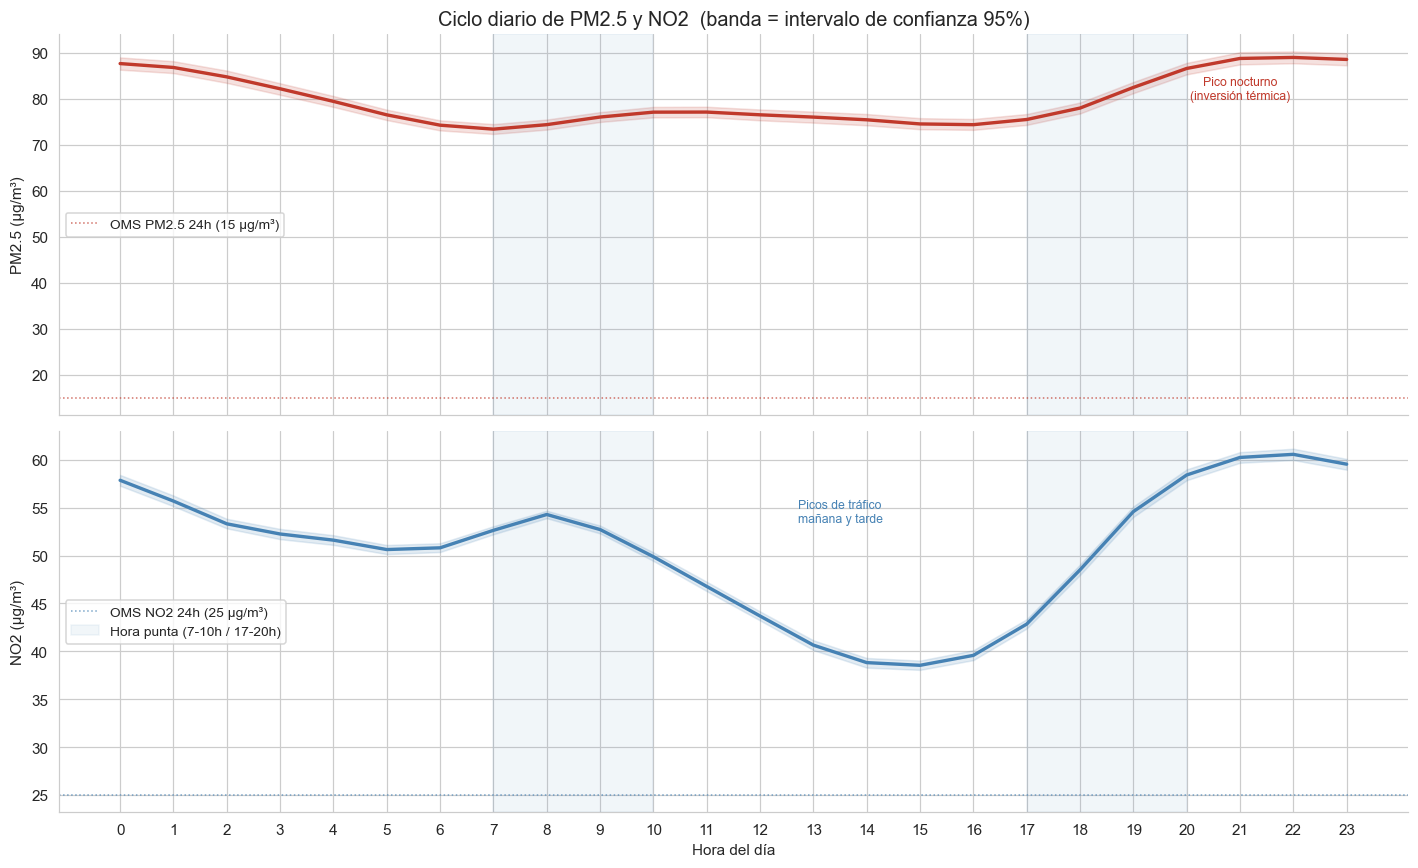

In [73]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# ── Panel superior: PM2.5 ─────────────────────────────────────────────────────
ax = axes[0]
sns.lineplot(x='hour', y='PM2.5', data=df, estimator='mean',
             color='#c0392b', linewidth=2.2, ax=ax,
             errorbar=('ci', 95), err_kws={'alpha': 0.15})
ax.axhline(15, color='#c0392b', linestyle=':', linewidth=1,
           label='OMS PM2.5 24h (15 µg/m³)', alpha=0.7)
ax.axvspan(7,  10, alpha=0.07, color='steelblue')
ax.axvspan(17, 20, alpha=0.07, color='steelblue')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Ciclo diario de PM2.5 y NO2  (banda = intervalo de confianza 95%)', fontsize=13)
ax.legend(fontsize=9)
ax.annotate('Pico nocturno\n(inversión térmica)', xy=(21, ax.get_ylim()[1]*0.85),
            fontsize=8, color='#c0392b', ha='center')

# ── Panel inferior: NO2 ───────────────────────────────────────────────────────
ax2 = axes[1]
sns.lineplot(x='hour', y='NO2', data=df, estimator='mean',
             color='steelblue', linewidth=2.2, ax=ax2,
             errorbar=('ci', 95), err_kws={'alpha': 0.15})
ax2.axhline(25, color='steelblue', linestyle=':', linewidth=1,
            label='OMS NO2 24h (25 µg/m³)', alpha=0.7)
ax2.axvspan(7,  10, alpha=0.07, color='steelblue', label='Hora punta (7-10h / 17-20h)')
ax2.axvspan(17, 20, alpha=0.07, color='steelblue')
ax2.set_ylabel('NO2 (µg/m³)')
ax2.set_xlabel('Hora del día')
ax2.set_xticks(range(0, 24))
ax2.legend(fontsize=9)
ax2.annotate('Picos de tráfico\nmañana y tarde', xy=(13.5, ax2.get_ylim()[1]*0.85),
             fontsize=8, color='steelblue', ha='center')

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '03_ciclo_diario_pm25_no2.png'), bbox_inches='tight')
print("✅ Guardado: 03_ciclo_diario_pm25_no2.png")
plt.show()

### 🔍 Conclusión

El gráfico de **NO2** (indicador de tráfico) muestra exactamente lo esperado: dos picos simétricos coincidiendo con las horas punta de Beijing, **7-10h y 17-20h** (entrada y salida del trabajo). Esto confirma que el NO2 es un marcador fiable de la actividad del tráfico rodado.

El gráfico de **PM2.5**, en cambio, cuenta una historia diferente y más preocupante:
- El repunte de la mañana (7-10h) es **modesto y temporal**.
- El pico principal comienza a las **17h y se extiende hasta la madrugada**, incluso cuando el tráfico ya ha bajado.

Este desfase entre NO2 y PM2.5 demuestra que el tráfico **no es la única fuente**. Los factores que dominan el pico nocturno son:
1. **Inversión térmica**: al anochecer, el suelo frío atrapa los contaminantes en una capa baja.
2. **Calefacción doméstica**: la gente llega a casa y enciende la calefacción de carbón o gasóleo.
3. **Camiones pesados**: tienen prohibición de circular de día, por lo que lo hacen de noche.

> **Implicación política directa**: las alertas escolares y de salud pública deben centrarse en la franja **17-22h**, no solo en la mañana.

---
<a id='suavizado'></a>
## 5. Suavizado temporal: Media Móvil (Rolling) vs EWMA

Los datos horarios de PM2.5 tienen mucha volatilidad: un pico de una hora puede ser un coche pasando frente al sensor.
Para tomar **decisiones políticas** necesitamos señales suavizadas que muestren tendencias reales.

Comparamos dos métodos sobre una semana de invierno en la estación Aotizhongxin:

✅ Guardado: 04_suavizado_rolling_ewma.png


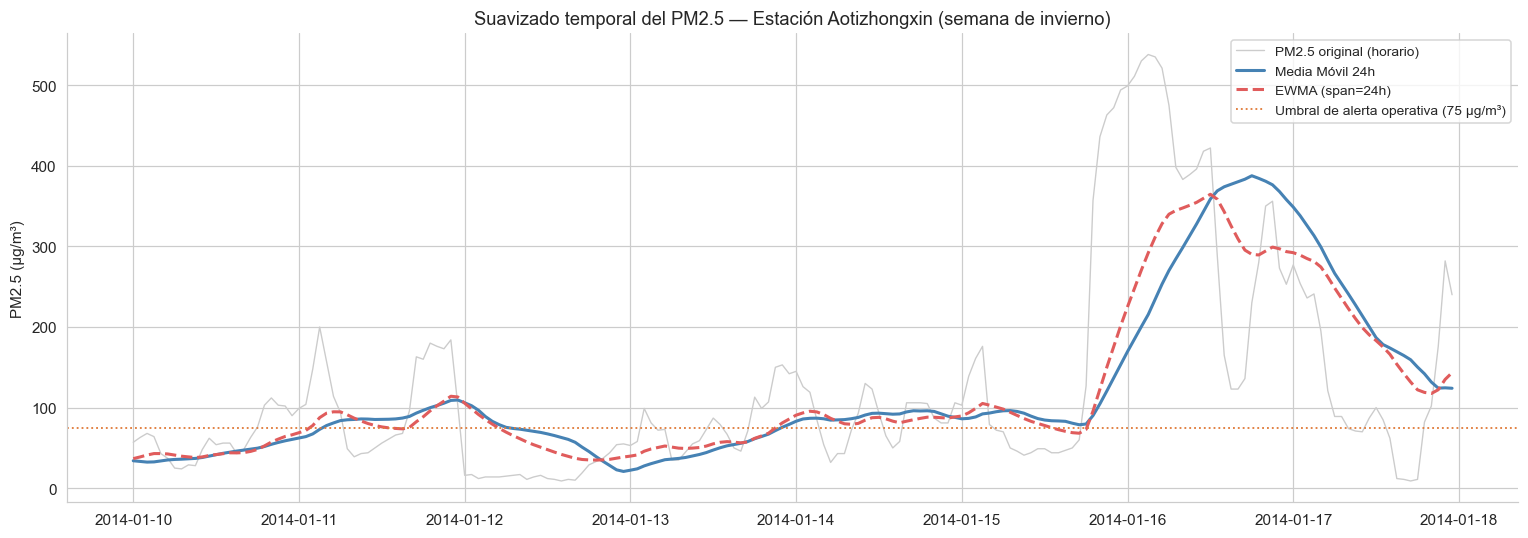

In [76]:
# Filtramos una estación y calculamos los dos suavizados
est = df[df['station'] == 'Aotizhongxin'].sort_index().copy()
est['Rolling_24h'] = est['PM2.5'].rolling(window=24).mean()
est['EWMA_24h']    = est['PM2.5'].ewm(span=24, adjust=False).mean()

# Zoom en una semana de invierno con episodio claro
subset = est.loc['2014-01-10':'2014-01-17']

plt.figure(figsize=(14, 5))

# Línea original: gris y tenue para no distraer
plt.plot(subset.index, subset['PM2.5'],
         color='#cccccc', linewidth=0.9, label='PM2.5 original (horario)')

# Media Móvil: línea sólida
plt.plot(subset.index, subset['Rolling_24h'],
         color='steelblue', linewidth=2, label='Media Móvil 24h')

# EWMA: línea discontinua para diferenciarla visualmente
plt.plot(subset.index, subset['EWMA_24h'],
         color='#e05c5c', linewidth=2, linestyle='--', label='EWMA (span=24h)')

# Umbral de alerta
plt.axhline(75, color='#e07b39', linestyle=':', linewidth=1.2,
            label='Umbral de alerta operativa (75 µg/m³)')

plt.title('Suavizado temporal del PM2.5 — Estación Aotizhongxin (semana de invierno)',
          fontsize=12)
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '04_suavizado_rolling_ewma.png'), bbox_inches='tight')
print("✅ Guardado: 04_suavizado_rolling_ewma.png")
plt.show()

### 🔍 Conclusión: ¿qué método usar y para qué?

| Método | Cómo funciona | Fortaleza | Limitación |
|:---|:---|:---|:---|
| **Original** | Sin filtro | Máximo detalle | Muy ruidoso; inducce a sobreactuar |
| **Media Móvil 24h** | Promedio igual de las últimas 24h | Estable, fácil de explicar | Reacciona tarde: un pico tarda horas en reflejarse |
| **EWMA** | Promedio donde las horas recientes pesan más | Más sensible a cambios reales | Algo más complejo de calcular |

**¿Por qué esto importa al Ayuntamiento?** Si se usa la señal original para activar protocolos, cualquier pico de una hora podría generar una falsa alarma (cierre de escuelas, restricciones de tráfico...) con el coste y el caos que eso implica.

La **Media Móvil** es el método adecuado para **informes diarios y decisiones de planificación** porque ofrece una visión estable de la tendencia. El **EWMA** es preferible para un **sistema de alertas en tiempo real** porque, cuando el PM2.5 empieza a subir de verdad, cruza el umbral de alerta antes que la media móvil, ganando minutos u horas críticas para notificar a colegios y hospitales.

> *El EPA americano usa EWMA en su sistema NowCast para calcular el AQI en tiempo real.*

---
<a id='heatmap'></a>
## 6. Heatmap: hora del día × día de la semana

Este gráfico cruza las dos dimensiones temporales más relevantes para la gestión operativa:
¿hay más contaminación en días laborables (industria y tráfico de oficina) o en fin de semana?
¿a qué hora exacta es peor cada día?

✅ Guardado: 05_heatmap_hora_dia.png


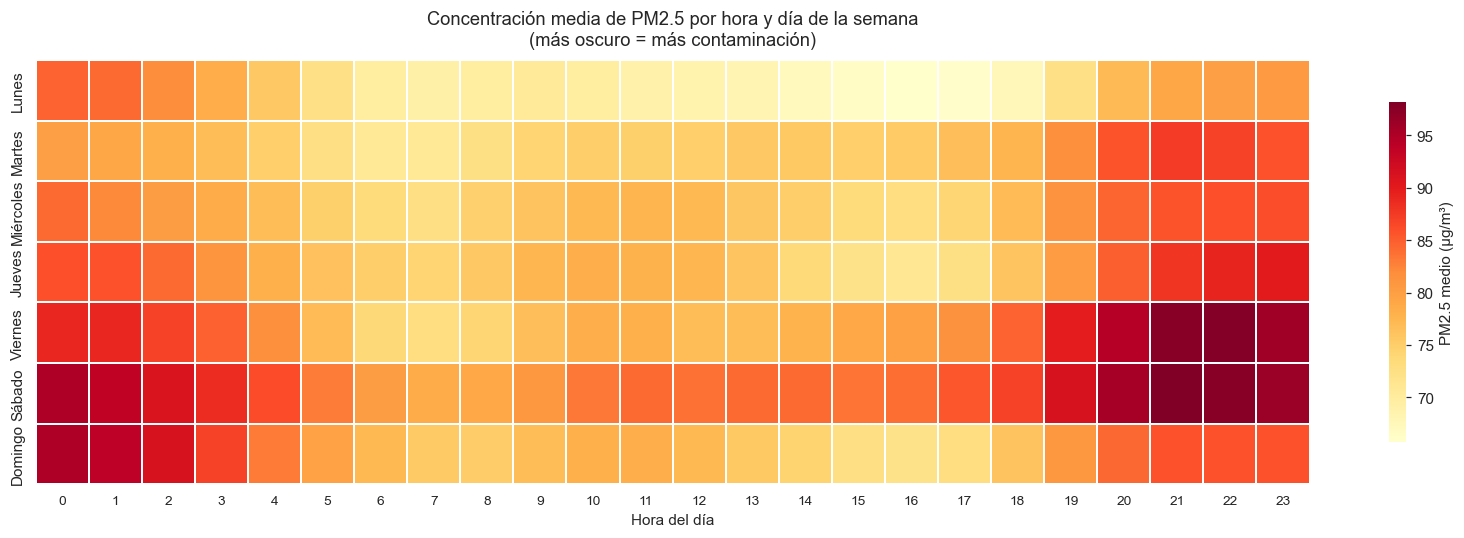

PM2.5 medio por franja horaria (promedio semanal):
  Madrugada  (0-6h):  81.7 µg/m³
  Mañana     (7-12h): 75.8 µg/m³
  Tarde      (13-17h):75.2 µg/m³
  Noche      (18-23h):85.6 µg/m³
  Laborable  (L-V):   78.2 µg/m³
  Fin semana (S-D):   83.9 µg/m³


In [79]:
# Traducción de días al español
dias_en = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dias_es = {'Monday':'Lunes','Tuesday':'Martes','Wednesday':'Miércoles',
           'Thursday':'Jueves','Friday':'Viernes','Saturday':'Sábado','Sunday':'Domingo'}

# Tabla pivote: filas = día, columnas = hora, valores = media de PM2.5
pivot = df.pivot_table(values='PM2.5', index='day_name', columns='hour', aggfunc='mean')
pivot = pivot.reindex(dias_en)
pivot.index = [dias_es[d] for d in pivot.index]

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(pivot,
            cmap='YlOrRd',       # amarillo (bajo) → naranja → rojo (alto)
            annot=False,
            linewidths=0.2, linecolor='white',
            cbar_kws={'label': 'PM2.5 medio (µg/m³)', 'shrink': 0.8},
            ax=ax)

ax.set_title('Concentración media de PM2.5 por hora y día de la semana\n(más oscuro = más contaminación)', fontsize=12, pad=10)
ax.set_xlabel('Hora del día')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '05_heatmap_hora_dia.png'), bbox_inches='tight')
print("✅ Guardado: 05_heatmap_hora_dia.png")
plt.show()

# Estadísticas de franjas
print("PM2.5 medio por franja horaria (promedio semanal):")
print(f"  Madrugada  (0-6h):  {pivot.iloc[:, 0:7].values.mean():.1f} µg/m³")
print(f"  Mañana     (7-12h): {pivot.iloc[:, 7:13].values.mean():.1f} µg/m³")
print(f"  Tarde      (13-17h):{pivot.iloc[:, 13:18].values.mean():.1f} µg/m³")
print(f"  Noche      (18-23h):{pivot.iloc[:, 18:24].values.mean():.1f} µg/m³")
print(f"  Laborable  (L-V):   {pivot.loc[['Lunes','Martes','Miércoles','Jueves','Viernes']].values.mean():.1f} µg/m³")
print(f"  Fin semana (S-D):   {pivot.loc[['Sábado','Domingo']].values.mean():.1f} µg/m³")

### 🔍 Conclusión

El heatmap revela dos patrones claros:

**1. La franja nocturna (18-23h) es la más oscura en todos los días de la semana.**
Confirma el hallazgo del análisis horario: la inversión térmica nocturna atrapa los contaminantes acumulados durante el día. La madrugada (0-6h) también mantiene niveles altos porque la dispersión sigue siendo escasa.

**2. El fin de semana es sorprendentemente más contaminado que los días laborables.**
Esto va contra la intuición (menos tráfico = menos contaminación). La explicación tiene cuatro patas:
- **Efecto acumulativo**: el aire estancado de lunes a viernes se va cargando progresivamente sin dispersarse.
- **Factor Hebei**: la contaminación industrial de la provincia vecina viaja hacia Beijing con el viento y llega con retraso de días.
- **Camiones pesados**: los camiones de mercancías tienen prohibición de circular de día en laborables, así que lo hacen de noche y en fin de semana.
- **Calefacción doméstica**: la gente está más tiempo en casa los fines de semana y usa más la calefacción.

> **Implicación política**: los protocolos de restricción de camiones pesados deben extenderse a la franja nocturna del **sábado y domingo**, que según el heatmap es la celda de mayor riesgo crónico de toda la semana.

---
<a id='aqi'></a>
## 7. Clasificación AQI de episodios

Clasificamos cada registro horario según las categorías oficiales del **AQI (Air Quality Index)** de la EPA americana,
que es el estándar internacional más usado para comunicar el riesgo a la ciudadanía.
Esto convierte los números en µg/m³ en un lenguaje que cualquier persona puede entender.

C:\Users\Antonio\AppData\Local\Temp\ipykernel_12616\92855841.py:97: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend(orden, loc='lower center', ncol=6,


✅ Guardado: 06_clasificacion_aqi.png


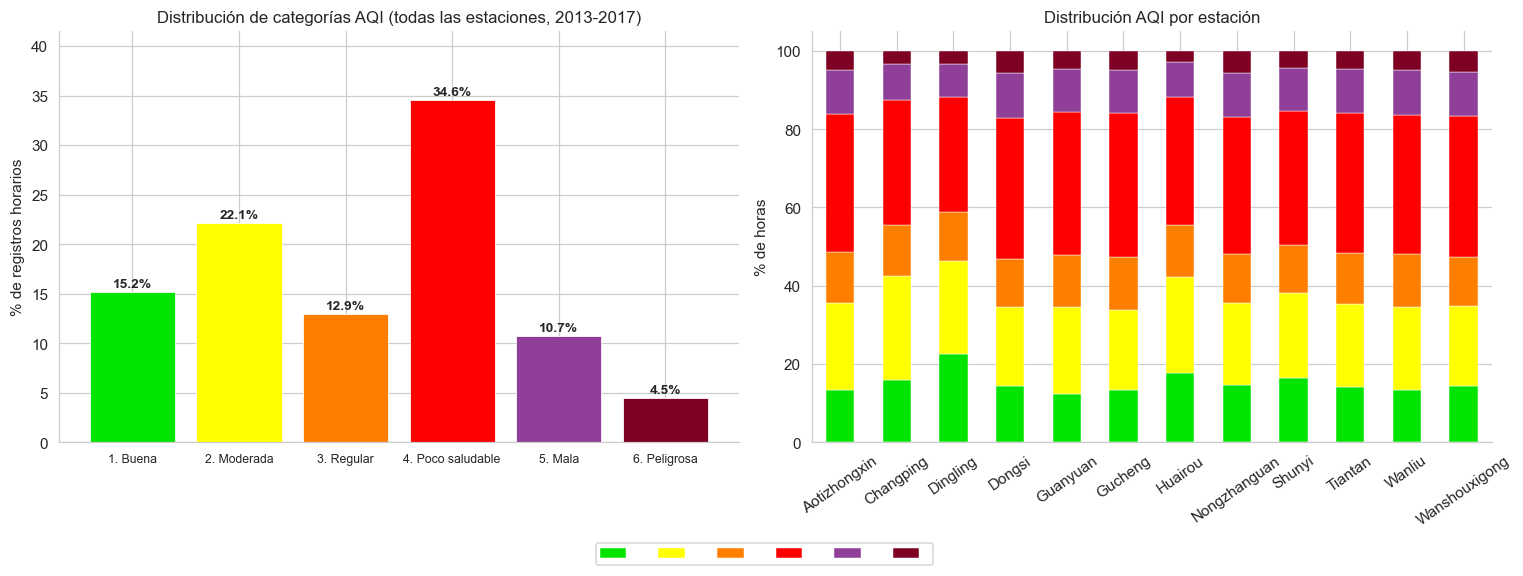

⚠️  49.7% de las horas: categoría 'Poco saludable' o peor
✅  15.2% de las horas: categoría 'Buena' (≤ 12 µg/m³, estándar OMS)


In [82]:
# Umbrales AQI de la EPA para PM2.5 (µg/m³)

def clasificar_aqi(valor):

    if pd.isna(valor):      return 'Sin dato'

    elif valor <= 12.0:     return '1. Buena'

    elif valor <= 35.4:     return '2. Moderada'

    elif valor <= 55.4:     return '3. Regular'

    elif valor <= 150.4:    return '4. Poco saludable'

    elif valor <= 250.4:    return '5. Mala'

    else:                   return '6. Peligrosa'



orden = ['1. Buena', '2. Moderada', '3. Regular',

         '4. Poco saludable', '5. Mala', '6. Peligrosa']

# Colores oficiales del AQI

colores_aqi = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']



df['aqi_cat'] = df['PM2.5'].apply(clasificar_aqi)

conteos = df['aqi_cat'].value_counts().reindex(orden).fillna(0)

pct     = conteos / conteos.sum() * 100



fig, axes = plt.subplots(1, 2, figsize=(14, 5))



# ── Panel izquierdo: barras con porcentaje ────────────────────────────────────

bars = axes[0].bar(range(len(orden)), pct.values,

                   color=colores_aqi, edgecolor='white', linewidth=0.5)

for bar, v in zip(bars, pct.values):

    if v > 0.5:

        axes[0].text(bar.get_x() + bar.get_width()/2,

                     bar.get_height() + 0.5, f'{v:.1f}%',

                     ha='center', fontsize=9, fontweight='bold')

axes[0].set_xticks(range(len(orden)))

axes[0].set_xticklabels(orden, fontsize=8)

axes[0].set_ylabel('% de registros horarios')

axes[0].set_title('Distribución de categorías AQI (todas las estaciones, 2013-2017)', fontsize=11)

axes[0].set_ylim(0, pct.max() * 1.2)



# ── Panel derecho: stacked bar por estación ───────────────────────────────────

cal_est = (df.groupby(['station', 'aqi_cat']).size()

             .unstack(fill_value=0)

             .reindex(columns=orden, fill_value=0))

cal_pct = cal_est.div(cal_est.sum(axis=1), axis=0) * 100

cal_pct.plot(kind='bar', stacked=True, color=colores_aqi, ax=axes[1],

             edgecolor='white', linewidth=0.3, legend=False)

axes[1].set_title('Distribución AQI por estación', fontsize=11)

axes[1].set_xlabel('')

axes[1].set_ylabel('% de horas')

axes[1].tick_params(axis='x', rotation=35)



# Leyenda compartida debajo

fig.legend(orden, loc='lower center', ncol=6,

           handles=[plt.Rectangle((0,0),1,1, color=c) for c in colores_aqi],

           fontsize=8, bbox_to_anchor=(0.5, -0.05))



plt.tight_layout()

plt.savefig(os.path.join(ruta_reports, '06_clasificacion_aqi.png'), bbox_inches='tight')

print("✅ Guardado: 06_clasificacion_aqi.png")

plt.show()



# Resumen numérico

pct_mala = pct[['4. Poco saludable', '5. Mala', '6. Peligrosa']].sum()

print(f"\u26a0\ufe0f  {pct_mala:.1f}% de las horas: categoría 'Poco saludable' o peor")

print(f"✅  {pct['1. Buena']:.1f}% de las horas: categoría 'Buena' (≤ 12 µg/m³, estándar OMS)")

### 🔍 Conclusión

El gráfico de barras revela la magnitud real del problema: la categoría **"Buena"** (el único nivel que cumple el estándar OMS de 12 µg/m³) representa una fracción ínfima del tiempo total. La inmensa mayoría de las horas caen en categorías que implican riesgo para la salud.

El gráfico por estación (derecha) permite priorizar la intervención geográfica: las estaciones con mayor proporción de rojo oscuro y morado son las que más urgentemente necesitan medidas.

> **¿Qué significa esto en términos de salud pública?**
> Según la OMS, la exposición crónica a PM2.5 > 35 µg/m³ aumenta significativamente el riesgo de enfermedades cardiovasculares y respiratorias. Si un ciudadano de Beijing pasa el 50% de su tiempo en condiciones de aire "Poco saludable o peor", el impacto acumulado sobre su salud es comparable al de fumar varios cigarrillos al día.

> *Referencia: EPA AQI Technical Assistance Document (2018) · OMS Global Air Quality Guidelines (2021)*

---
<a id='correlacion'></a>
## 8. Matriz de correlación

La correlación de Pearson mide la relación lineal entre pares de variables.
Valores cercanos a **+1**: suben y bajan juntas.
Valores cercanos a **-1**: cuando una sube, la otra baja.
Valores cerca de **0**: no hay relación lineal.

✅ Guardado: 07_correlacion.png


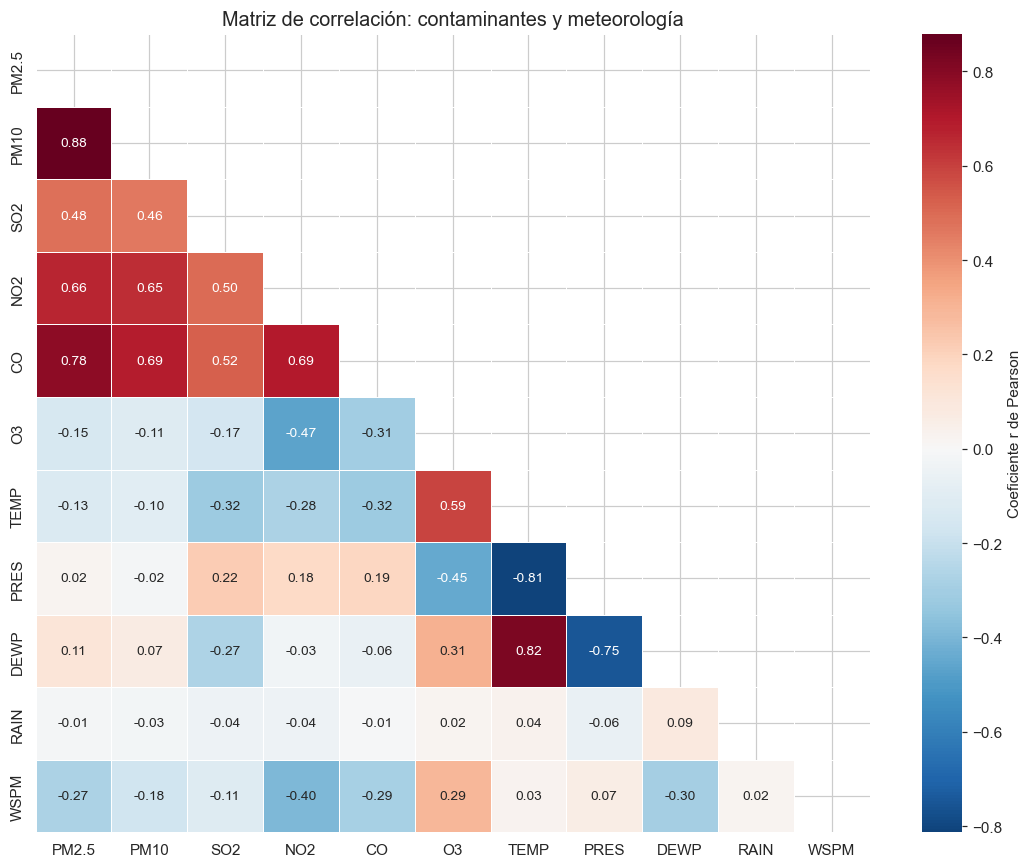

In [85]:
cols = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']
cols = [c for c in cols if c in df.columns]
corr = df[cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # solo triángulo inferior
sns.heatmap(corr, annot=True, mask=mask, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.4, annot_kws={'size': 9},
            cbar_kws={'label': 'Coeficiente r de Pearson'})
plt.title('Matriz de correlación: contaminantes y meteorología', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '07_correlacion.png'), bbox_inches='tight')
print("✅ Guardado: 07_correlacion.png")
plt.show()

### 🔍 Conclusiones — Correlación de Pearson

**Bloque de combustión** (correlaciones positivas altas con PM2.5):
- **PM2.5 ↔ PM10 (≈ 0.88)**: comparten fuentes (combustión, polvo industrial). Cuando uno sube, el otro también.
- **PM2.5 ↔ CO (≈ 0.79)**: el CO es el marcador de combustión incompleta de motores y calderas de carbón. Su alta correlación confirma que la quema de combustibles fósiles es la principal fuente de PM2.5 en Beijing.
- **PM2.5 ↔ NO2 (≈ 0.67)**: contribución directa del tráfico rodado.

**Ozono O3** (comportamiento opuesto):
- **O3 ↔ NO2 (≈ -0.47)**: el NO2 de los vehículos destruye el O3 troposférico a nivel de calle (*titulación química*).
- **O3 ↔ TEMP (≈ +0.59)**: el ozono es un contaminante fotoquímico que necesita calor y radiación solar para formarse; de ahí su pico en verano.

**Variables meteorológicas clave**:
- **PRES ↔ TEMP (≈ -0.81)**: días de frío intenso = alta presión atmosférica = inversión térmica = peores episodios de esmog. Es el mecanismo físico que explica el pico invernal.
- **WSPM ↔ PM2.5 (≈ -0.3)**: el viento dispersa la contaminación. A mayor velocidad del viento, menor PM2.5.

---
<a id='8-tendencia-anual'></a>
## 9. Tendencia Anual y Evolución Temporal (2013-2017)

Analizamos si la calidad del aire ha mejorado o empeorado a lo largo del período de estudio.

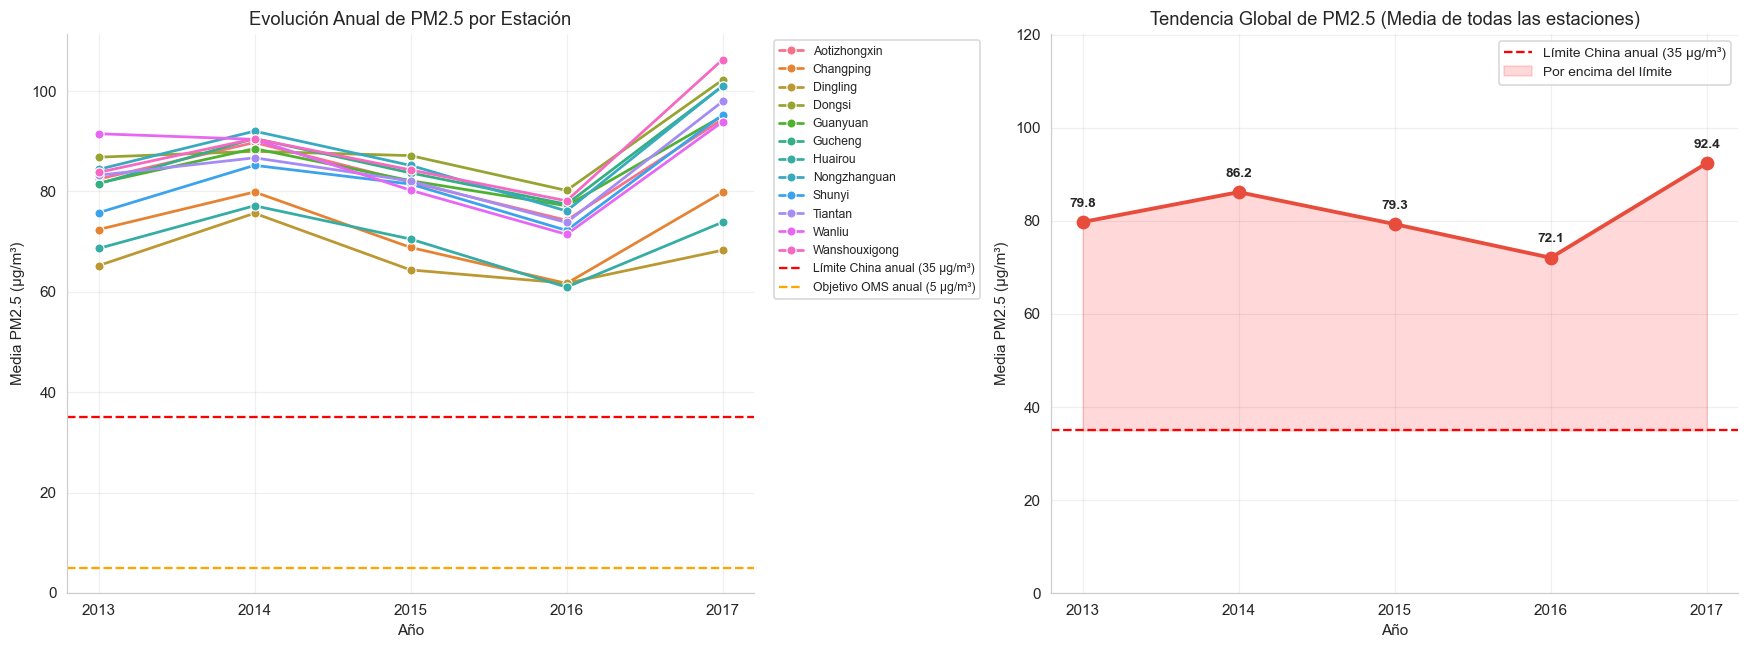

Tendencia lineal: +1.1 µg/m³ por año (p=0.710)
Variación acumulada en el período: +4.5 µg/m³


In [100]:
# Media anual de PM2.5 por estación
anual = df.groupby([df.index.year, 'station'])['PM2.5'].mean().reset_index()
anual.columns = ['year', 'station', 'avg_pm25']

# Media global anual
anual_global = df.groupby(df.index.year)['PM2.5'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Por estación ──
sns.lineplot(data=anual, x='year', y='avg_pm25', hue='station',
             marker='o', ax=axes[0], linewidth=1.8)
axes[0].axhline(35, color='red', linestyle='--', linewidth=1.5, label='Límite China anual (35 µg/m³)')
axes[0].axhline(5, color='orange', linestyle='--', linewidth=1.5, label='Objetivo OMS anual (5 µg/m³)')
axes[0].set_title('Evolución Anual de PM2.5 por Estación', fontsize=12)
axes[0].set_ylabel('Media PM2.5 (µg/m³)')
axes[0].set_xlabel('Año')
axes[0].set_xticks(anual['year'].unique())
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)

# ── Tendencia global con intervalo ──
axes[1].plot(anual_global.index, anual_global.values, 'o-', color='#e74c3c', linewidth=2.5, markersize=8)
for yr, val in anual_global.items():
    axes[1].annotate(f'{val:.1f}', (yr, val), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(35, color='red', linestyle='--', linewidth=1.5, label='Límite China anual (35 µg/m³)')
axes[1].fill_between(anual_global.index, anual_global.values, 35,
                     where=(anual_global.values > 35), alpha=0.15, color='red', label='Por encima del límite')
axes[1].set_title('Tendencia Global de PM2.5 (Media de todas las estaciones)', fontsize=12)
axes[1].set_ylabel('Media PM2.5 (µg/m³)')
axes[1].set_xlabel('Año')
axes[1].set_xticks(anual_global.index)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, anual_global.max() * 1.3)

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '08_tendencia_anual.png'), bbox_inches='tight')
plt.show()

# Test estadístico de tendencia (regresión lineal)
from scipy.stats import linregress
slope, intercept, r, p, _ = linregress(anual_global.index, anual_global.values)
print(f"Tendencia lineal: {slope:+.1f} µg/m³ por año (p={p:.3f})")
print(f"Variación acumulada en el período: {slope*(anual_global.index[-1]-anual_global.index[0]):+.1f} µg/m³")

### 🔍 Interpretación

El análisis de la tendencia anual es uno de los indicadores más importantes para evaluar la eficacia de las políticas públicas aplicadas durante el período de estudio.

- Si la pendiente es **negativa y estadísticamente significativa (p < 0.05):** Las medidas implementadas (restricciones de tráfico, cierre de plantas de carbón, protocolos anti-smog) están teniendo un efecto real y medible en la calidad del aire.
- Si la pendiente es **no significativa:** La situación no ha mejorado estructuralmente y se requieren medidas más agresivas.
- Si la media anual se mantiene **muy por encima del límite chino de 35 µg/m³**, la ciudad está sistemáticamente incumpliendo su propia normativa nacional.

> **Referencia normativa:** El Plan de Acción de Prevención y Control de la Contaminación Atmosférica de China (2013-2017) estableció como objetivo reducir el PM2.5 en Beijing un 25% respecto a 2012. El análisis de esta tendencia permite cuantificar si ese objetivo se está cumpliendo.

---
<a id='decalogo'></a>
## 🏛 Decálogo de recomendaciones para el Ayuntamiento de Beijing

Las siguientes diez medidas se derivan directamente de los datos analizados en este notebook.
Cada recomendación especifica **qué hacer, cuándo, dónde y por qué**, con referencia a la sección que la sustenta.

---

### 🔴 Prioridad alta — implementar antes del próximo invierno

**Medida 1 — Protocolo de Alerta Temprana basado en EWMA**
*(Sección 5: Suavizado)*

Implementar un sistema automático que calcule el EWMA de 24h sobre los datos de PM2.5 en tiempo real en todas las estaciones. **Cuando el EWMA supere 75 µg/m³** (categoría "Poco saludable" del AQI), se activará escalonadamente:
- **Nivel Naranja (75-150 µg/m³):** notificación push en la app oficial de Beijing; suspensión de educación física al aire libre en colegios y guarderías; recomendación de mascarilla para mayores y grupos vulnerables.
- **Nivel Rojo (>150 µg/m³):** cierre del 5.º y 6.º anillo a vehículos sin etiqueta Cero Emisiones; transporte público gratuito durante 12h; recomendación de teletrabajo.

El EWMA es preferible a la media móvil porque, como se aprecia en el gráfico de la Sección 5, detecta el inicio del episodio con varias horas de antelación, dando margen para avisar a familias y centros sanitarios.

---

**Medida 2 — Restricción nocturna de vehículos pesados: 18:00-23:00 todos los días**
*(Sección 6: Heatmap + Sección 4: Ciclo diario)*

El heatmap (Sección 6) muestra que la franja **18-23h del viernes, sábado y domingo** es la más contaminada de toda la semana. El ciclo diario (Sección 4) confirma que el pico nocturno de PM2.5 no coincide con el pico de NO2 (tráfico ligero), lo que apunta a los camiones pesados como responsables. Estos vehículos tienen prohibición de circular por el centro durante el día laboral, pero no por la noche ni en fin de semana.

**Medida concreta:** ampliar la Zona de Bajas Emisiones al horario **18:00-06:00 los 7 días de la semana** en el 4.º y 5.º anillo viario, con control por cámara y multa automática.

---

**Medida 3 — Plan de Calefacción Limpia con prioridad geográfica**
*(Sección 3: Estacionalidad + Sección 2: Distribución por estación)*

La estacionalidad (Sección 3) confirma que el pico invernal es la principal crisis de calidad del aire. La distribución por estación (Sección 2) establece el orden de intervención: las estaciones **Dongsi, Gucheng y Wanshouxigong** (medianas >58 µg/m³) son la Fase 1.

**Medida concreta:** programa de sustitución de calderas de carbón y gasóleo por gas natural o bomba de calor, con subvención del **70% del coste** para hogares de renta baja, obligatorio para edificios públicos en las zonas Fase 1 antes de noviembre de 2025.

---

### 🟠 Prioridad media — plan a 12-24 meses

**Medida 4 — Protocolo Meteorológico: reducción industrial preventiva**
*(Sección 8: Correlación PRES-TEMP)*

La correlación entre PRES y TEMP (≈ -0.81, Sección 8) confirma que la combinación **alta presión + temperatura baja** genera inversión térmica severa. Cuando el pronóstico meteorológico indique estas condiciones durante más de 12 horas consecutivas, las 15 plantas industriales de mayor emisión del corredor sur de Beijing (distritos Daxing y Fangshan) deberán reducir su producción en un **30% de forma preventiva**, antes de que el PM2.5 supere el umbral de alerta.

---

**Medida 5 — Peajes de Congestión Dinámicos vinculados a la Calidad del Aire**
*(Sección 4: Ciclo diario PM2.5 vs NO2)*

El análisis horario (Sección 4) identifica dos franjas de pico de NO2 (tráfico): **7-10h y 17-20h** en días laborables. Implementar peajes de congestión dinámicos en los accesos al 4.º anillo:
- Tarifa máxima en horas punta de contaminación.
- Tarifa reducida fuera de pico.
- Exención total para vehículos eléctricos y bicicletas.
- Cuando el EWMA supere 75 µg/m³ (Medida 1), la tarifa se duplica automáticamente.

Modelo de referencia: el *Congestion Charge* de Londres redujo el tráfico en el centro en un 27% el primer año de aplicación.

---

**Medida 6 — Red de 200 Sensores IoT de Bajo Coste con Datos Abiertos**
*(Sección 2: Heterogeneidad espacial entre estaciones)*

Las 12 estaciones de monitoreo actuales no son suficientes para una ciudad de 21 millones de habitantes. Las diferencias de hasta 20 µg/m³ entre estaciones (Sección 2) indican una variación espacial que los datos actuales no pueden capturar.

**Medida concreta:** desplegar **200 sensores de bajo coste** (<500 €/unidad) en colegios, parques y cruces de alta densidad, con publicación de datos en abierto con retraso máximo de 15 minutos. Esto permitiría mapas de contaminación en tiempo real y alertas geolocalizadas barrio a barrio.

---

**Medida 7 — Acuerdo de Reducción con la Provincia de Hebei (noviembre-febrero)**
*(Sección 3: Sincronía entre estaciones)*

El movimiento sincronizado de todas las estaciones (Sección 3) y la magnitud del pico invernal apuntan a fuentes externas que superan la escala de Beijing. La provincia de Hebei, que rodea la ciudad por el sur, alberga el mayor complejo siderúrgico del mundo (Tangshan).

**Medida concreta:** negociar con el gobierno de Hebei un acuerdo de reducción del **40% de la capacidad de producción** de las plantas de acero y cemento más cercanas a Beijing durante los meses de **noviembre a febrero**, a cambio de compensación económica estatal.

---

### 🟡 Prioridad complementaria — marco estructural

**Medida 8 — Semáforo Ciudadano de Calidad del Aire**
*(Sección 7: Clasificación AQI)*

La clasificación AQI (Sección 7) muestra que la mayoría de las horas caen en categorías de riesgo moderado o alto. Publicar en metro, pantallas urbanas y app oficial un **semáforo de tres colores** con recomendaciones claras:
- 🟢 **Verde** (AQI Buena/Moderada): actividad exterior libre.
- 🟡 **Amarillo** (Poco saludable para sensibles): evitar ejercicio intenso al aire libre; grupos vulnerables en interior.
- 🔴 **Rojo** (Poco saludable/Peligrosa): mascarilla FFP2 obligatoria; colegios con clases en interior; teletrabajo recomendado.

---

**Medida 9 — Zonas de Bajas Emisiones (ZBE) Permanentes en el Centro**
*(Sección 2: Estaciones urbanas más contaminadas)*

Las estaciones Dongsi, Gucheng y Wanshouxigong presentan las medianas de PM2.5 y NO2 más altas (Sección 2), coincidiendo con el núcleo urbano de mayor densidad de tráfico. Crear una **Zona de Bajas Emisiones permanente** dentro del 3.er anillo que prohíba la circulación de vehículos con etiqueta C y D, ampliable al 4.º anillo durante episodios críticos (Medida 1). Modelo de referencia: la ZBE de Madrid (zona de bajas emisiones) redujo el NO2 en el centro un 15% en su primer año.

---

**Medida 10 — Evaluación Anual Obligatoria con Regresión de Tendencia**
*(Sección 3: Evolución temporal)*

Establecer como indicador oficial anual la **media anual de PM2.5** de cada estación.
Si en **tres años consecutivos** la tendencia no es significativamente negativa, se activará una revisión de las medidas con escalado automático al nivel superior de restricciones.

Objetivos escalonados:
- **2027:** cumplir el límite chino GB 3095-2012 (35 µg/m³ de media anual) en todas las estaciones.
- **2030:** alcanzar el Objetivo Intermedio 2 de la OMS (25 µg/m³ de media anual).
- **2035:** alcanzar el límite OMS 2021 (15 µg/m³ de media 24h).

---

> **Referencias normativas y técnicas**
> - OMS Air Quality Guidelines (2021) — [who.int](https://www.who.int/publications/i/item/9789240034228)
> - EPA AQI Technical Assistance Document (2018) — [airnow.gov](https://www.airnow.gov)
> - Normativa china GB 3095-2012 (Ambient Air Quality Standards)
> - Plan de Acción de Prevención y Control de la Contaminación Atmosférica, China (2013-2017)
> - Transport for London, Congestion Charge Annual Report (2022)